In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot

import freealg
from freealg import AlgebraicForm
from freealg.distributions import MarchenkoPastur, ChiralBlock, CompoundFreePoisson, FreeLevy
from freealg.visualization import plot_flow, plot_mass, ridgeplot

plot_dir = './plots'
save_filename = 'algebraic-compound-poisson'
title = 'Compound Free Poisson'
latex = True

# Compound Free Poisson

[(0.9984996249062267, 3.13165791447862), (4.157389347336835, 7.597674418604652)]


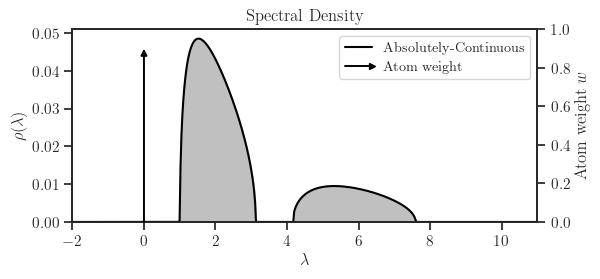

In [2]:
lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dist = CompoundFreePoisson(t=[t1, t2], w=[w1, 1-w1], lam=lam)
# dist = FreeLevy(t=[t1, t2], w=[w1, 1-w1], lam=lam, a=0.0, sigma=0.0)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=True, save=False)

# Submatrix

In [3]:
A = dist.matrix(6000, seed=0)
eig_A = numpy.linalg.eigvalsh(A)

numpy.save(join(plot_dir, 'A.npy'), A)
numpy.save(join(plot_dir, 'eig_A.npy'), eig_A)

In [4]:
A = numpy.load(join(plot_dir, 'A.npy'))
eig_A = numpy.load(join(plot_dir, 'eig_A.npy'))

In [5]:
As = freealg.submatrix(A, 1000, seed=1)
eig_As = numpy.linalg.eigvalsh(As)

# Fit Spectral Curve

fit residual max  : 2.4177e-01
fit residual 99.9%: 1.9856e-02

Coefficients (real)
+1.00000000 +0.95743515 +0.12142385 +0.00000000 
+0.00000000 +1.00000000 +1.24459378 +0.30355962 

Coefficients (imag) norm: 0.0000e+00

Stieltjes sanity check: OK


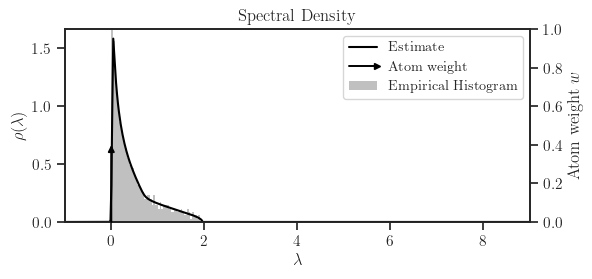


------------------------------------------
Mass: 0.61125650

------------------------------------------
Support (detected from histogram):
	Interval 1: (  -0.0000,    1.9096)

------------------------------------------
Support (estimated from polynomial):
	Interval 1: (   0.0196,    1.9603)

------------------------------------------
Atoms (estimated from polynomial):
	Atom 1. x: -1.8e-13, weight: 40.0%

------------------------------------------
is decompressible: True


In [6]:
# af = AlgebraicForm(dist)
af = AlgebraicForm(eig_As, support=None, delta=1e-5)

deg_m = 3
deg_z = 1

coeffs = af.fit(
    deg_m, deg_z, reg=0, normalize=True, triangular=None,
    mu='auto', mu_reg=None, verbose=True)

x = numpy.linspace(x_min, x_max, 500)
rho0 = af.density(x, plot=True, latex=latex)

# Check mass (at start size)
print('\n------------------------------------------')
mass = numpy.trapz(rho0, x)
print(f'Mass: {mass:0.8f}')

# Detect support from histogram
support = freealg.supp(eig_As)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

print('\n------------------------------------------')
print('Support (estimated from polynomial):')
est_supp = af.support()
for i, supp in enumerate(est_supp):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

print('\n------------------------------------------')
print('Atoms (estimated from polynomial):')
for i, atom in enumerate(af.atoms()):
    print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, weight: {100.0*atom[1]:>4.1f}%')

print('\n------------------------------------------')
status = af.is_decompressible()
print(f'is decompressible: {status}')

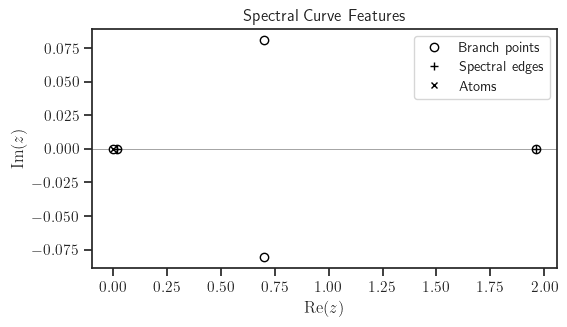


i   Branch Points        Spectral Edge
--  -------------------  -------------
1    +1.9603+0.000e+00i  Maybe
2    +0.6982+8.071e-02i  No
3    +0.6982-8.071e-02i  No
4    +0.0196+0.000e+00i  Maybe
5    -0.0000+0.000e+00i  Maybe


In [7]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True, latex=latex)

# A branch point on real axis is a candidate to also be a spectral edge.
# Those with near zero imaginary part are flagged as maybe a spectral edge.
print('\ni   Branch Points        Spectral Edge')
print('--  -------------------  -------------')
for i in range(bp.size):
    print(f'{i+1}   {bp[i].real:>+8.4f}{bp[i].imag:>+5.3e}i', end='  ')
    if numpy.abs(bp[i].imag) < 1e-14:
        print('Maybe')
    else:
        print('No')

# Free Decompression

success rate per t: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


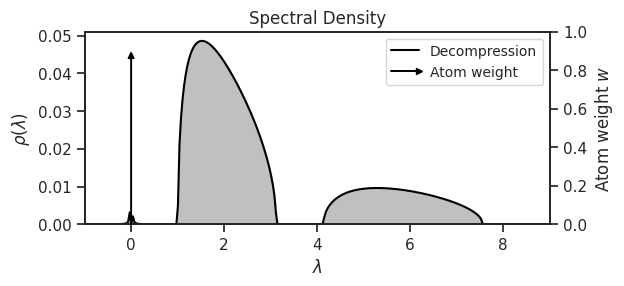

In [8]:
# newton_opt = {'sweep': True}
# newton_opt = {
#     'sweep': True,
#     'sweep_pad': 200,          # much larger than 20
#     'active_imag_eps': 5e-7,   # or ~ 1*eta instead of 50*eta
# }

# -----------------------
# for _decompress.py
# newton_opt = {
#     # 'min_n_times': 50,
#     'sweep': True,
#     'sweep_pad': 30,
#     'active_imag_eps': 1e-6,
# }
# ------------------------
# ---------------------------
## For _decompress4.py
# newton_opt = {
#     "sweep": False,
#     "viterbi_opt": {
#         "lam_space": 1.0,
#         "lam_time": 0.25,
#         "lam_im": 10.0,      # hinge only
#         "edge_k": 12,
#         "lam_asym": 5.0,
#         "lam_norm": 20.0,    # important
#         "refine_newton": True,
#     },
# }

# ---------------------
# newton_opt = {}
# newton_opt = dict(newton_opt)
# newton_opt["eta_hi"] = 3.0
# newton_opt["n_eta"] = 24
# newton_opt["anchor_radius"] = 0.6
# newton_opt["herglotz_tol"] = 0.0  # your convention: Im(m)>0

# newton_opt["viterbi_opt"] = dict(
#     lam_time=0.25,
#     lam_space=1.0,
#     lam_asym=0.2,
#     lam_im2=0.0,     # <-- set to 0 for now
#     edge_k=8,
# )


# ---------------------------

# -------------------------
# For _decompress6.py

# newton_opt = {}
# newton_opt["eta_hi"] = 3.0
# newton_opt["n_eta"] = 24
# newton_opt["anchor_radius"] = 0.6
# newton_opt["herglotz_tol"] = 0.0

# newton_opt["edge_use"] = True
# newton_opt["edge_support"] = est_supp     # <-- from af.fit
# newton_opt["edge_pad"] = 0.0
# newton_opt["im_floor_rel"] = 0.5         # try 0.10–0.30
# newton_opt["w_min"] = 1e-14               # kills the 0j root

# newton_opt["viterbi_opt"] = dict(
#     lam_time=0.25,
#     lam_space=1.0,
#     lam_asym=0.2,
#     lam_im2=0.0,
#     edge_k=8,
# )

# -------------------------

# _defompress7.py
# newton_opt = {}
# newton_opt = dict(
#     max_iter=40, tol=1e-13,
#     damping=1.0, step_clip=5.0,
#     max_split=0,      # IMPORTANT: disable extra intermediate tau tries
#     sweep=False,      # IMPORTANT: avoid bad cross-x seeding
#     require_imw_pos=True, im_eps=1e-14,
#     verbose=False, debug=False,
# )

# newton_opt = dict(
#     max_iter=40, tol=1e-13, damping=1.0,
#     step_clip=5.0, max_split=0, sweep=False,
#     require_imw_pos=True, im_eps=1e-14,
#     verbose=False, debug=False,
# )

# newton_opt['sweep'] = False
# newton_opt = dict(
#     max_iter=40, tol=1e-13, damping=1.0,
#     step_clip=5.0, max_split=8,      # <--- important
#     require_imw_pos=True, im_eps=1e-14,
#     verbose=False, debug=False,
# )


# Evolve
# rho, x = af.decompress([2000, 3000, 4000, 8000], method='one', newton_opt=newton_opt,
#                     verbose=True, plot=True)
# sizes = numpy.arange(1, 4.1, 0.5)
# sizes = numpy.arange(1, 1.5, 0.05)  # For def MP
# sizes = numpy.arange(1, 1, 0.05)  # For def MP
# sizes = [1.0, 1.01, 1.02, 1.05] 
# sizes = numpy.array([1.0, 1.01])   # smallest step first
# sizes = numpy.arange(1, 1.8, 0.25)
# x = numpy.linspace(0, 12, 100)  # for deformed MP
# x = numpy.linspace(0.5, 9, 100)  # for deformed MP
# x = numpy.linspace(-1, 8, 500)  # for deformed MP
# x = numpy.linspace(-2, 6, 500)
# af.n = As.shape[0]
# x = numpy.linspace(x_min, x_max, 100)

newton_opt = {}
x = numpy.linspace(x_min, x_max, 300)
fd_sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)

rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True,
    atom_eps=1e-2,
    verbose=True, plot=True, latex=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-flow.pdf".


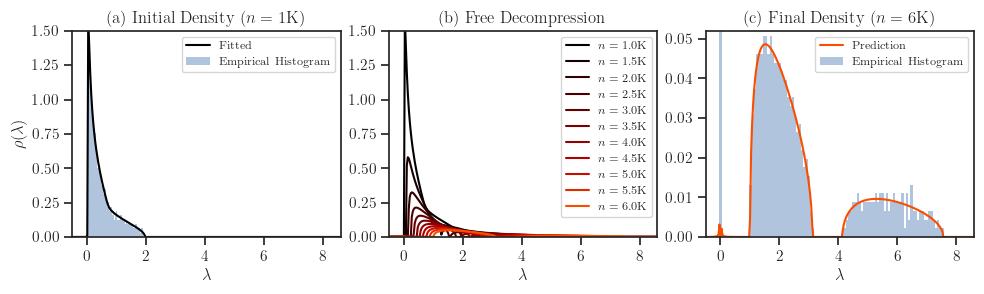

In [9]:
plot_flow(fd_sizes, x, rho, eig_As, eig_A, xlim=[-0.5, 8.6],
          ylim=(1.5, 1.5, 0.052), share_ax=False, layout='horizontal',
          title='Free Decompression',
          cmap=plt.cm.gist_heat,
          c_range=(0.0, 0.65),
          hist_color='lightsteelblue',
          nbins=(60, 100),
          label_mode='dec',
          save=join(plot_dir, save_filename + '-flow.pdf'),
          latex=latex)

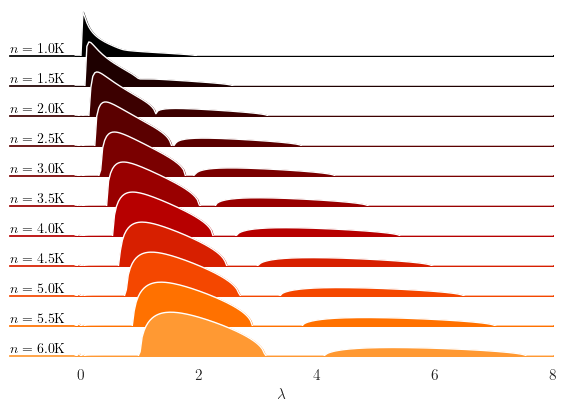

In [10]:
mask = x > -0.1
ridgeplot(fd_sizes, x=x[mask], rho=rho[:, mask], eigs=None,
          log=False, scaley=True, hspace=-0.35, rho_color='white',
          text_side='left', xlim=(-1.2, 8), figsize=(7, 4.5),
          label_mode='dec', latex=latex, save=False, nbins=200)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-mass.pdf".


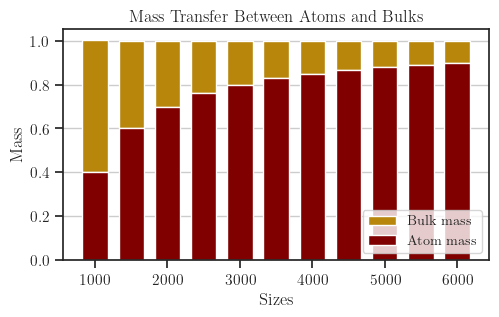

In [11]:
plot_mass(fd_sizes, x, rho, atoms=atoms, gap=0.7, latex=latex,
          save=join(plot_dir, save_filename + '-mass.pdf'))

# Edge and Cusp

In [12]:
t_cusp = numpy.linspace(0, 2, 100)
cusps = af.cusp(t_cusp)

print('Cusps:')
for cusp in cusps:
    x_cusp, t_cusp = cusp
    print(f'\tx: {x_cusp:>0.3f}, t: {t_cusp:>0.3f}')

if len(cusps) > 0:
    x_cusp, t_cusp = cusps[0]
else:
    x_cusp, t_cusp = None, None

Cusps:
	x: 1.245, t: 0.671


In [13]:
t = numpy.linspace(0, 2, 500)
complex_edges, real_merged_edges, active_k = af.edge(t)

In [14]:
from matplotlib.collections import PolyCollection

# ===============
# fill split bulk
# ===============

def fill_split_bulk(ax, t, edges, color, alpha=0.05, zorder=-2, width_tol=1e-12):
    """
    Seam-free fill for one->two bifurcation using a single PolyCollection.

    Assumes 4 columns layout:
        [a1, a2, b2, b1] where a2,b2 are NaN before split.

    Builds trapezoids between consecutive time samples so there are no
    gaps/overlaps at the cusp.
    """

    t = numpy.asarray(t, dtype=float)
    E = numpy.asarray(edges, dtype=float)

    a1 = E[:, 0]
    a2 = E[:, 1]
    b2 = E[:, 2]
    b1 = E[:, 3]

    polys = []

    def add_strip(i, xL0, xR0, xL1, xR1):
        # Require finite and positive width at both ends
        if not (numpy.isfinite(xL0) and numpy.isfinite(xR0) and numpy.isfinite(xL1) and numpy.isfinite(xR1)):
            return
        if (xR0 - xL0) <= width_tol or (xR1 - xL1) <= width_tol:
            return
        y0 = t[i]
        y1 = t[i+1]
        polys.append([(xL0, y0), (xR0, y0), (xR1, y1), (xL1, y1)])

    for i in range(len(t) - 1):
        # If split edges exist at i and i+1 -> fill two bulks
        split_i  = numpy.isfinite(a2[i])  and numpy.isfinite(b2[i])
        split_ip = numpy.isfinite(a2[i+1]) and numpy.isfinite(b2[i+1])

        if split_i and split_ip:
            # left bulk: [a1, a2]
            add_strip(i, a1[i], a2[i], a1[i+1], a2[i+1])
            # right bulk: [b2, b1]
            add_strip(i, b2[i], b1[i], b2[i+1], b1[i+1])
        else:
            # single bulk: [a1, b1]
            add_strip(i, a1[i], b1[i], a1[i+1], b1[i+1])

    if not polys:
        return

    coll = PolyCollection(
        polys,
        facecolors=[color],
        edgecolors="none",
        closed=True,
        alpha=alpha,
        zorder=zorder)
    
    ax.add_collection(coll)

In [14]:
from matplotlib.collections import PolyCollection
import numpy as np

def fill_bulks(ax, t, edges, color, alpha=0.05, zorder=-2, width_tol=1e-12):
    """
    Seam-free fill for multiple bulks, generic 2k-column edges.
    Works as long as the number of *active bulks* does not change between
    consecutive time samples. (Insert cusp times into t to ensure that.)
    """
    t = np.asarray(t, dtype=float)
    E = np.asarray(edges, dtype=float)

    polys = []

    def add_strip(y0, y1, xL0, xR0, xL1, xR1):
        if not (np.isfinite(xL0) and np.isfinite(xR0) and np.isfinite(xL1) and np.isfinite(xR1)):
            return
        if (xR0 - xL0) <= width_tol or (xR1 - xL1) <= width_tol:
            return
        polys.append([(xL0, y0), (xR0, y0), (xR1, y1), (xL1, y1)])

    for i in range(len(t) - 1):
        e0 = E[i, :]
        e1 = E[i + 1, :]

        f0 = e0[np.isfinite(e0)]
        f1 = e1[np.isfinite(e1)]

        # Need complete pairs
        if (len(f0) % 2) != 0 or (len(f1) % 2) != 0:
            continue

        # If bulks count changes inside this step, skip (avoid wrong pairing)
        if len(f0) != len(f1):
            continue

        f0 = np.sort(f0)
        f1 = np.sort(f1)

        y0 = t[i]
        y1 = t[i + 1]

        nb = len(f0) // 2
        for j in range(nb):
            xL0, xR0 = f0[2*j], f0[2*j + 1]
            xL1, xR1 = f1[2*j], f1[2*j + 1]
            add_strip(y0, y1, xL0, xR0, xL1, xR1)

    if not polys:
        return

    coll = PolyCollection(
        polys,
        facecolors=[color],
        edgecolors="none",
        closed=True,
        alpha=alpha,
        zorder=zorder
    )
    ax.add_collection(coll)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-edge.pdf".


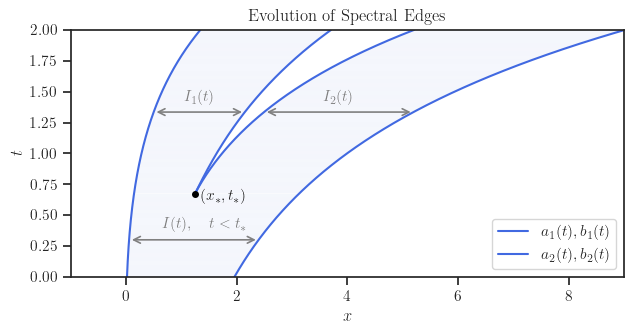

In [17]:
# k = len(support)
k = real_merged_edges.shape[1] // 2

# colors = ['royalblue', 'maroon']
colors = ['royalblue', 'royalblue']
fill_color = 'royalblue'

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    for j in range(k):
        a_r = real_merged_edges[:, 2*j + 0]
        b_r = real_merged_edges[:, 2*j + 1]

        a_c = complex_edges[:, 2*j + 0].real
        b_c = complex_edges[:, 2*j + 1].real

        # Plot spectral edges with solid lines
        ax.plot(a_r, t, color=colors[j], label=rf'$a_{{{j+1}}}(t), b_{{{j+1}}}(t)$')
        ax.plot(b_r, t, color=colors[j])

        # Plot ghost edges with dashed lines
        # m_a = numpy.isnan(a_r)
        # m_b = numpy.isnan(b_r)
        # ax.plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
        # ax.plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)

        # Fill between (does not work with bifurcation, use fill_split_bulk)
        # ax.fill_betweenx(t, a_c, b_c, color=colors[j], alpha=0.05, zorder=-2)
        
        # --------
        # Plot I_j
        # --------
        
        t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.75 * t[-1]
        # t_mid = 0.8 * t[-1]
        j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
        
        ax.annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
        
        ax.text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                fr'$I_{{{j+1}}}(t)$',
                color='gray', ha='center', va='bottom', fontsize=11)

    # Fill between edges includign the bifurcated egdes
    # fill_split_bulk(ax, t, real_merged_edges, color='royalblue', alpha=0.05, zorder=-2)
    fill_bulks(ax, t, real_merged_edges, color=fill_color, alpha=0.05, zorder=-2)

    # ----------------
    # Plot I_1 cup I_2
    # ----------------
    
    a_all = real_merged_edges[:, 0]
    b_all = real_merged_edges[:, -1]

    t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
    j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
    
    ax.annotate('', xy=(b_all[j_mid2], t[j_mid2]), xytext=(a_all[j_mid2], t[j_mid2]),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    
    ax.text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
            # r'$I_1(t) \cup I_2(t)$',
            r'$I(t), \quad t < t_{\ast}$',
            color='gray', ha='center', va='bottom', fontsize=11)

    # ---------------------

    # Cusp
    if 't_cusp' in globals():
        ax.plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
        ax.text(x_cusp + 0.12, t_cusp - 0.05, r'$(x_{\ast}, t_{\ast})$', fontsize=11)

    ax.set_xlim([x_min, x_max])
    ax.set_ylim([t[0], t[-1]])
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_title(r'Evolution of Spectral Edges')
    ax.legend()
    plt.tight_layout()

    save_full_filename = join(plot_dir, save_filename + '-edge.pdf')
    texplot.show_or_save_plot(plt, default_filename=save_full_filename,
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)

# Edge and Histogram

In [17]:
t_final = numpy.log(fd_sizes[-1] / fd_sizes[0])
t = numpy.linspace(0.0, t_final, 1000)
complex_edges, real_merged_edges, active_k = af.edge(t, verbose=True)

edge success rate: 1.0


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-edge-hist.pdf".


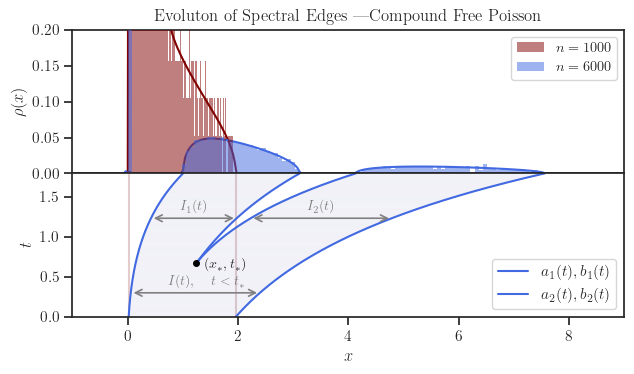

In [21]:
# k = len(support)
k = real_merged_edges.shape[1] // 2

# colors = ['royalblue', 'maroon']
colors = ['royalblue', 'royalblue']

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.9), nrows=2, sharex=True) 

    # Histogram
    ax[0].hist(eig_As, 100, density=True, zorder=10, alpha=0.5, color='maroon',
               edgecolor='none', label=rf'$n = {{{fd_sizes[0]}}}$')
    ax[0].hist(eig_A, 100, density=True, zorder=10, alpha=0.5, color='royalblue',
               edgecolor='none', label=rf'$n = {{{fd_sizes[-1]}}}$')
    
    ax[0].set_xlim([x[0], x[-1]])
    # ax[0].set_ylim(bottom=0)
    ax[0].set_ylim([0, 0.2])
    # ax[0].set_xlabel(r'$x$')
    ax[0].set_ylabel(r'$\rho(x)$')
    ax[0].set_title(r'Evoluton of Spectral Edges |' + title)
    ax[0].legend(fontsize='small')
    # ax[0].tick_params(labelbottom=False)
    ax[0].tick_params(axis='x', bottom=False, labelbottom=False)

    # rho
    # num_plots = rho.shape[0]
    # cmap = plt.get_cmap('gist_heat')
    # colors = [cmap(i/(num_plots + 2)) for i in range(num_plots + 1)][1:]
    ax[0].plot(x, rho[0], color='maroon')
    ax[0].plot(x, rho[-1], color='royalblue')
    
    for j in range(k):
        a_r = real_merged_edges[:, 2*j + 0]
        b_r = real_merged_edges[:, 2*j + 1]

        a_c = complex_edges[:, 2*j + 0].real
        b_c = complex_edges[:, 2*j + 1].real

        # Plot spectral edges with solid lines
        ax[1].plot(a_r, t, color=colors[j], label=rf'$a_{{{j+1}}}(t), b_{{{j+1}}}(t)$')
        ax[1].plot(b_r, t, color=colors[j])

        # Plot ghost edges with dashed lines
        m_a = numpy.isnan(a_r)
        m_b = numpy.isnan(b_r)
        ax[1].plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
        ax[1].plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)

        # Fill between
        # ax[1].fill_betweenx(t, a_c, b_c, color=colors[j], alpha=0.05, zorder=-2)

        ax[1].axvline(a_c[0], color='maroon',alpha=0.2, zorder=-10)
        ax[1].axvline(b_c[0], color='maroon', alpha=0.2, zorder=-10)
        
        # --------
        # Plot I_j
        # --------
        
        t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.5 * t[-1]
        j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
        
        ax[1].annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
        
        ax[1].text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                fr'$I_{{{j+1}}}(t)$',
                color='gray', ha='center', va='bottom', fontsize=10)

    fill_split_bulk(ax[1], t, real_merged_edges, color='royalblue', alpha=0.05, zorder=-2)

    # ----------------
    # Plot I_1 cup I_2
    # ----------------
    
    a_all = real_merged_edges[:, 0]
    b_all = real_merged_edges[:, -1]

    t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
    j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
    
    ax[1].annotate('', xy=(float(b_all[j_mid2]), t[j_mid2]),
                   xytext=(float(a_all[j_mid2]), t[j_mid2]),
                   arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    
    ax[1].text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
               # r'$I_1(t) \cup I_2(t)$',
               r'$I(t), \quad t < t_{\ast}$',
               color='gray', ha='center', va='bottom', fontsize=10)

    # ----
    # Cusp
    # ----
    
    if 't_cusp' in globals():
        ax[1].plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
        ax[1].text(x_cusp + 0.15, t_cusp - 0.07, r'$(x_{\ast}, t_{\ast})$', fontsize=10)

    ax[1].set_xlim([x_min, x_max])
    ax[1].set_ylim([t[0], t[-1]])
    ax[1].set_xlabel(r'$x$')
    ax[1].set_ylabel(r'$t$')
    # ax[1].set_title(r'Evolution of Spectral Edges')
    ax[1].legend()

    # --------------
    
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.0)

    save_full_filename = join(plot_dir, save_filename + '-edge-hist.pdf')
    texplot.show_or_save_plot(plt, default_filename=save_full_filename,
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)